# 2.1 - Salary Regression Model

**Goal:** Replace mean imputation of `normalized_salary` with a regression model.  
Trained on rows where salary is known (~29%), then used to predict the missing ~71%.

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import warnings

In [123]:
%matplotlib inline

## 1. Load Feature Matrices

In [124]:
TRAIN_PATH = "../data/processed/v1/feature_matrix_train.csv"
TEST_PATH  = "../data/processed/v1/feature_matrix_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"\nSalary missing in train: {df_train['normalized_salary'].isna().sum():,} "
      f"({df_train['normalized_salary'].isna().mean():.1%})")
print(f"Salary missing in test:  {df_test['normalized_salary'].isna().sum():,} "
      f"({df_test['normalized_salary'].isna().mean():.1%})")

Train shape: (98589, 44)
Test shape:  (24709, 44)

Salary missing in train: 62,448 (63.3%)
Salary missing in test:  15,750 (63.7%)


## 2. Prepare Regression Dataset

Split the training set into rows that have salary (used to train/validate the regressor) and rows that are missing salary (to be imputed).

In [125]:
TARGET = 'normalized_salary'
CLASSIFICATION_TARGET = 'experience_level_ord'

# Exclude columns that would leak salary info or aren't useful
EXCLUDE_COLS = [
    TARGET,
    CLASSIFICATION_TARGET,
    'state_salary_enc',   # target-encoded from salary
    'fips_salary_enc',    # target-encoded from salary
]

feature_cols = [c for c in df_train.columns if c not in EXCLUDE_COLS]

# Rows with known salary = regression training data
has_salary = df_train[TARGET].notna()
df_reg_train = df_train[has_salary].copy()
df_reg_miss  = df_train[~has_salary].copy()

X_known = df_reg_train[feature_cols]
y_known = df_reg_train[TARGET]

print(f"Regression training rows: {len(X_known):,}")
print(f"Rows to impute (train):   {len(df_reg_miss):,}")
print(f"Features:                 {len(feature_cols)}")
print(f"\nTarget stats (known):")
y_known.describe().apply(lambda x: f"{x:,.0f}")

Regression training rows: 36,141
Rows to impute (train):   62,448
Features:                 40

Target stats (known):


count     36,141
mean      92,290
std       59,483
min            0
25%       48,880
50%       78,078
75%      120,000
max      925,000
Name: normalized_salary, dtype: object

In [126]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.models.tracking.experiment import run_experiment
from src.models.tracking.config import configure_mlflow
from src.utils.evaluation import compute_regression_metrics
from src.models.train.train_lightgbm import (
    train_lgbm_regressor,
    get_feature_importance as lgbm_reg_fi,
)
from src.models.train.train_xgboost import (
    train_xgboost_regressor,
    get_feature_importance as xgb_reg_fi,
)
from src.models.train.train_catboost import (
    train_catboost_regressor,
    predict_regressor as catboost_predict_reg,
    get_feature_importance as cb_reg_fi,
)

configure_mlflow(experiment_name="salary-regression")

'2'

## 3. Train LightGBM Regressor

In [127]:
params = {
    "boosting_type": "gbdt",
    "learning_rate": 0.008,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_estimators": 5000,
}

X_tr, X_val, y_tr, y_val = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42
)

result = run_experiment(
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,
    y_test=y_val,
    train_fn=train_lgbm_regressor,
    eval_fn=compute_regression_metrics,
    feature_importance_fn=lgbm_reg_fi,
    model_type="lightgbm",
    task="regression",
    params=params,
    register_model_name="lightgbm",
    dataset_name="feature_matrix_train_v1",
    train_source=TRAIN_PATH,
)

lgbm_model = result["model"]
val_preds = lgbm_model.predict(X_val)
mae  = result["metrics"]["mae"]
rmse = result["metrics"]["rmse"]
r2   = result["metrics"]["r2"]

print(f"Run ID: {result['run_id']}")
print(f"Validation set ({len(X_val):,} rows):")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R2:   {r2:.4f}")
print(f"  Best iteration: {lgbm_model.best_iteration_}")

c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have mi

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 36297.3
[200]	valid_0's l1: 33512.3
[300]	valid_0's l1: 32276.3
[400]	valid_0's l1: 31585
[500]	valid_0's l1: 31163
[600]	valid_0's l1: 30913
[700]	valid_0's l1: 30750.7
[800]	valid_0's l1: 30634.7
[900]	valid_0's l1: 30532.9
[1000]	valid_0's l1: 30465.9
[1100]	valid_0's l1: 30386.2
[1200]	valid_0's l1: 30326.2
[1300]	valid_0's l1: 30284.9
[1400]	valid_0's l1: 30246.2
[1500]	valid_0's l1: 30203.6
[1600]	valid_0's l1: 30170.9
[1700]	valid_0's l1: 30144.3
[1800]	valid_0's l1: 30133.1
[1900]	valid_0's l1: 30117.4
[2000]	valid_0's l1: 30102.9
[2100]	valid_0's l1: 30084.3
[2200]	valid_0's l1: 30065.4
[2300]	valid_0's l1: 30064
[2400]	valid_0's l1: 30034.2
[2500]	valid_0's l1: 30023.8
[2600]	valid_0's l1: 30015.7
[2700]	valid_0's l1: 30002.8
[2800]	valid_0's l1: 29994.4
[2900]	valid_0's l1: 29984.4
[3000]	valid_0's l1: 29979.6
[3100]	valid_0's l1: 29969.2
[3200]	valid_0's l1: 29959.8
[3300]	valid_0's l1: 29945.

2026/06/08 09:40:27 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'lightgbm' already exists. Creating a new version of this model...
Created version '29' of model 'lightgbm'.


Run ID: 4af3a71fd1da42629d050c1b1a1af0ea
Validation set (7,229 rows):
  MAE:  $30,081
  RMSE: $47,878
  R2:   0.3822
  Best iteration: 3416


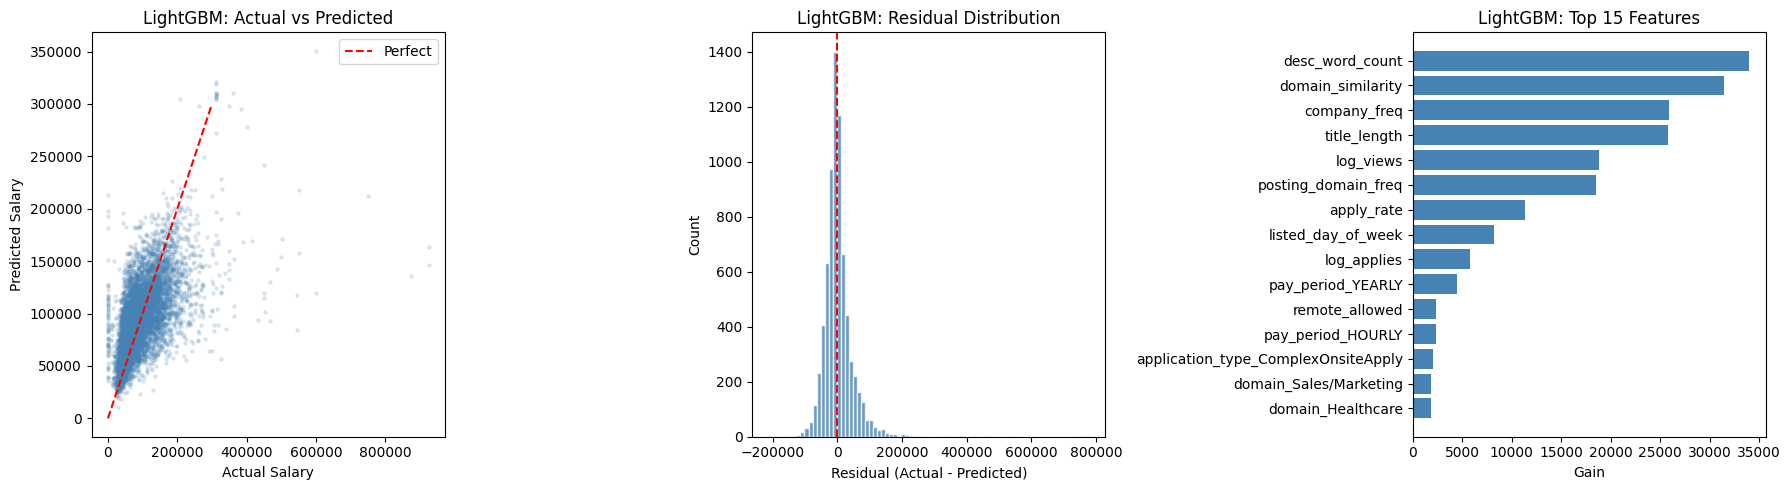

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a. Actual vs Predicted
ax = axes[0]
ax.scatter(y_val, val_preds, alpha=0.15, s=5, color='steelblue')
lims = [y_val.min(), y_val.quantile(0.99)]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual Salary')
ax.set_ylabel('Predicted Salary')
ax.set_title('LightGBM: Actual vs Predicted')
ax.legend()

# 4b. Residual distribution
ax = axes[1]
residuals = y_val - val_preds
ax.hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title('LightGBM: Residual Distribution')

# 4c. Feature importance (top 15)
ax = axes[2]
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('LightGBM: Top 15 Features')

plt.tight_layout()
plt.show()

## 4. Train XGBoost Regressor

In [129]:
xgb_params = {
    "learning_rate": 0.008,
    "max_depth": 0,
    "max_leaves": 63,
    "min_child_weight": 30,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_estimators": 5000,
}

xgb_result = run_experiment(
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,
    y_test=y_val,
    train_fn=train_xgboost_regressor,
    eval_fn=compute_regression_metrics,
    feature_importance_fn=xgb_reg_fi,
    model_type="xgboost",
    task="regression",
    params=xgb_params,
    register_model_name="xgboost",
    dataset_name="feature_matrix_train_v1",
    train_source=TRAIN_PATH,
)

xgb_model = xgb_result["model"]
xgb_val_preds = xgb_model.predict(X_val)
xgb_mae  = xgb_result["metrics"]["mae"]
xgb_rmse = xgb_result["metrics"]["rmse"]
xgb_r2   = xgb_result["metrics"]["r2"]

print(f"Run ID: {xgb_result['run_id']}")
print(f"Validation set ({len(X_val):,} rows):")
print(f"  MAE:  ${xgb_mae:,.0f}")
print(f"  RMSE: ${xgb_rmse:,.0f}")
print(f"  R2:   {xgb_r2:.4f}")
print(f"  Best iteration: {xgb_model.best_iteration}")

c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


[0]	validation_0-mae:43753.17450


c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


[100]	validation_0-mae:36778.64065
[200]	validation_0-mae:34053.25971
[300]	validation_0-mae:32792.51600
[400]	validation_0-mae:32097.82956
[500]	validation_0-mae:31658.62473
[600]	validation_0-mae:31353.16036
[700]	validation_0-mae:31119.88988
[800]	validation_0-mae:30942.55472
[900]	validation_0-mae:30786.18976
[1000]	validation_0-mae:30671.23323
[1100]	validation_0-mae:30589.92304
[1200]	validation_0-mae:30513.13316
[1300]	validation_0-mae:30464.86546
[1400]	validation_0-mae:30415.48533
[1500]	validation_0-mae:30377.23919
[1600]	validation_0-mae:30343.18412
[1700]	validation_0-mae:30315.49450
[1800]	validation_0-mae:30275.66239
[1900]	validation_0-mae:30251.06927
[2000]	validation_0-mae:30226.72191
[2100]	validation_0-mae:30202.43737
[2200]	validation_0-mae:30182.68319
[2300]	validation_0-mae:30167.05858
[2400]	validation_0-mae:30157.55288
[2500]	validation_0-mae:30146.51634
[2600]	validation_0-mae:30128.66140
[2700]	validation_0-mae:30120.92246
[2800]	validation_0-mae:30119.48752
[

Registered model 'xgboost' already exists. Creating a new version of this model...
Created version '14' of model 'xgboost'.


Run ID: bf2142d7939748d7a892a9e6f7d08284
Validation set (7,229 rows):
  MAE:  $30,232
  RMSE: $47,960
  R2:   0.3801
  Best iteration: 3002


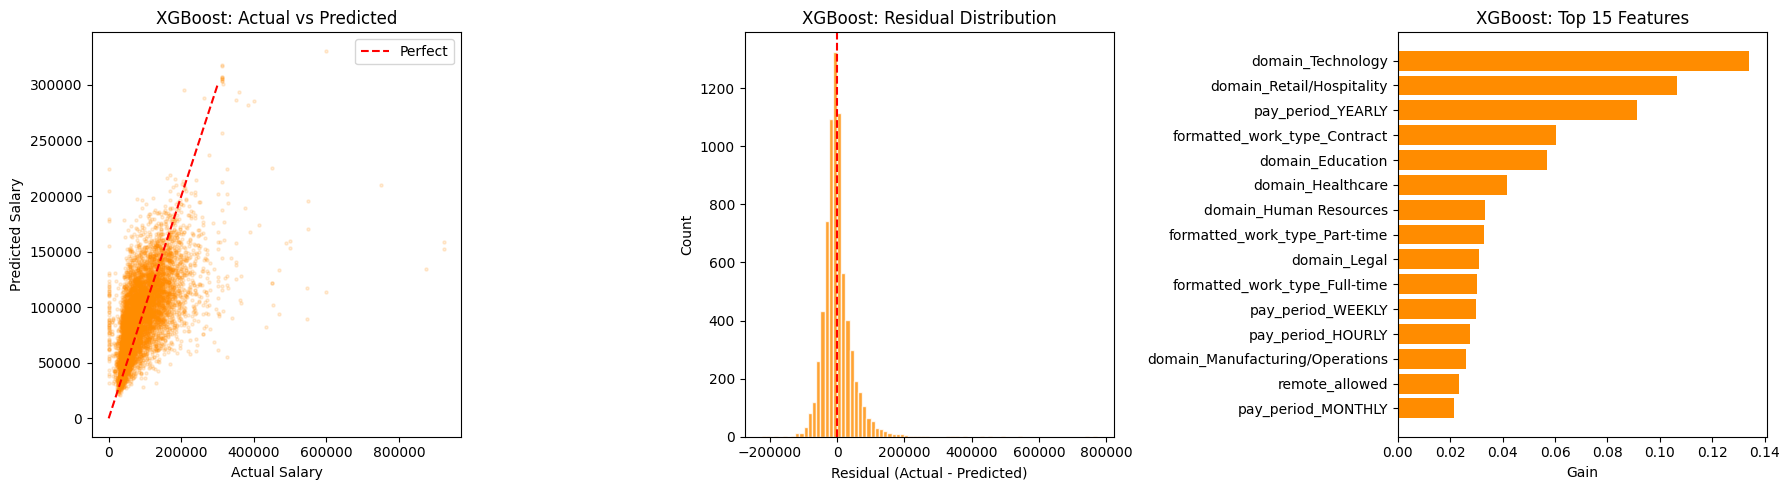

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(y_val, xgb_val_preds, alpha=0.15, s=5, color='darkorange')
lims = [y_val.min(), y_val.quantile(0.99)]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual Salary')
ax.set_ylabel('Predicted Salary')
ax.set_title('XGBoost: Actual vs Predicted')
ax.legend()

ax = axes[1]
xgb_residuals = y_val - xgb_val_preds
ax.hist(xgb_residuals, bins=80, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title('XGBoost: Residual Distribution')

ax = axes[2]
xgb_imp = xgb_reg_fi(xgb_model, feature_cols, top_n=15).sort_values()
ax.barh(xgb_imp.index, xgb_imp.values, color='darkorange')
ax.set_xlabel('Gain')
ax.set_title('XGBoost: Top 15 Features')

plt.tight_layout()
plt.show()

## 5. Train CatBoost Regressor

In [131]:
cb_params = {
    "iterations": 5000,
    "learning_rate": 0.008,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "subsample": 0.8,
}

cb_result = run_experiment(
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,
    y_test=y_val,
    train_fn=train_catboost_regressor,
    eval_fn=compute_regression_metrics,
    feature_importance_fn=cb_reg_fi,
    predict_fn=catboost_predict_reg,
    model_type="catboost",
    task="regression",
    params=cb_params,
    register_model_name="catboost",
    dataset_name="feature_matrix_train_v1",
    train_source=TRAIN_PATH,
)

cb_model = cb_result["model"]
cb_val_preds = catboost_predict_reg(cb_model, X_val)
cb_mae  = cb_result["metrics"]["mae"]
cb_rmse = cb_result["metrics"]["rmse"]
cb_r2   = cb_result["metrics"]["r2"]

print(f"Run ID: {cb_result['run_id']}")
print(f"Validation set ({len(X_val):,} rows):")
print(f"  MAE:  ${cb_mae:,.0f}")
print(f"  RMSE: ${cb_rmse:,.0f}")
print(f"  R2:   {cb_r2:.4f}")
print(f"  Best iteration: {cb_model.get_best_iteration()}")

c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have mi

0:	learn: 43713.8736700	test: 43766.1330434	best: 43766.1330434 (0)	total: 3.69ms	remaining: 18.5s
100:	learn: 38101.2127526	test: 37979.4427326	best: 37979.4427326 (100)	total: 418ms	remaining: 20.3s
200:	learn: 35969.3752561	test: 35793.0652051	best: 35793.0652051 (200)	total: 816ms	remaining: 19.5s
300:	learn: 34890.6422624	test: 34715.8631680	best: 34715.8631680 (300)	total: 1.21s	remaining: 18.9s
400:	learn: 34270.9555474	test: 34124.2895572	best: 34124.2895572 (400)	total: 1.56s	remaining: 17.9s
500:	learn: 33823.2479356	test: 33698.8409559	best: 33698.8409559 (500)	total: 1.94s	remaining: 17.4s
600:	learn: 33478.2996104	test: 33388.6367220	best: 33388.6367220 (600)	total: 2.34s	remaining: 17.1s
700:	learn: 33204.5975275	test: 33144.4473101	best: 33144.4473101 (700)	total: 2.76s	remaining: 16.9s
800:	learn: 32969.1451155	test: 32939.1871637	best: 32939.1871637 (800)	total: 3.17s	remaining: 16.6s
900:	learn: 32765.6935754	test: 32771.8768603	best: 32771.8768603 (900)	total: 3.6s	r

Registered model 'catboost' already exists. Creating a new version of this model...
Created version '13' of model 'catboost'.


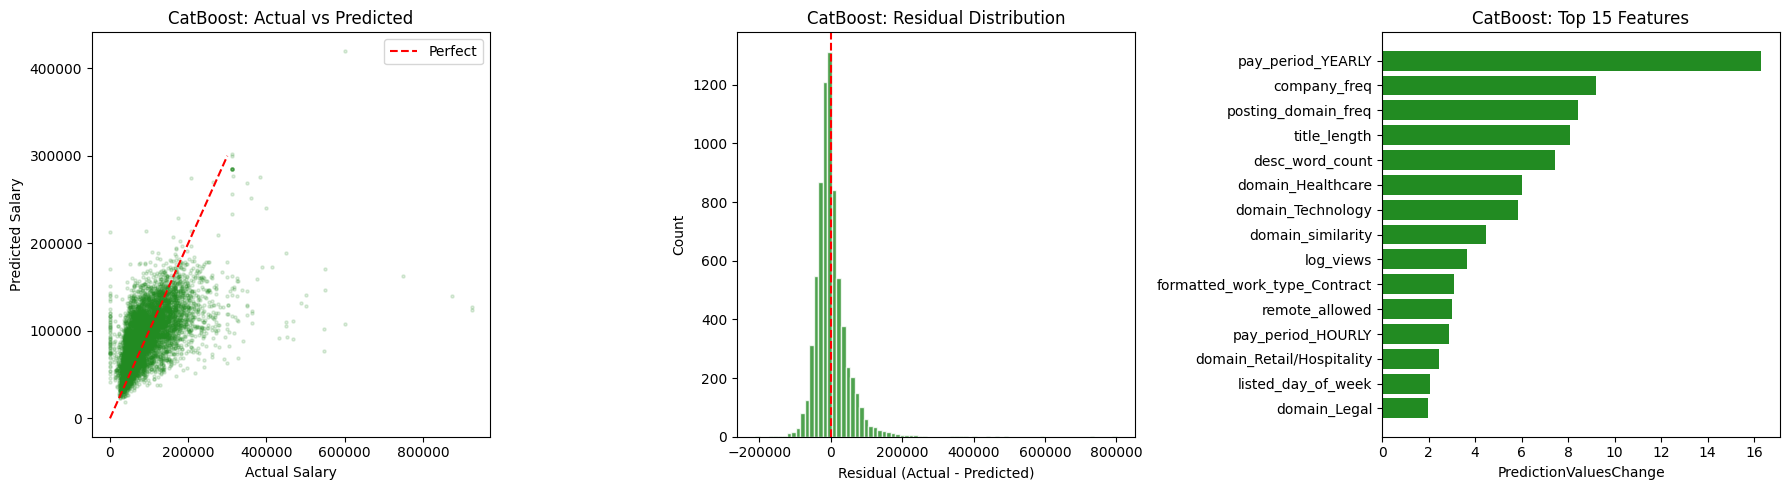

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(y_val, cb_val_preds, alpha=0.15, s=5, color='forestgreen')
lims = [y_val.min(), y_val.quantile(0.99)]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual Salary')
ax.set_ylabel('Predicted Salary')
ax.set_title('CatBoost: Actual vs Predicted')
ax.legend()

ax = axes[1]
cb_residuals = y_val - cb_val_preds
ax.hist(cb_residuals, bins=80, color='forestgreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title('CatBoost: Residual Distribution')

ax = axes[2]
cb_imp = cb_reg_fi(cb_model, feature_cols, top_n=15).sort_values()
ax.barh(cb_imp.index, cb_imp.values, color='forestgreen')
ax.set_xlabel('PredictionValuesChange')
ax.set_title('CatBoost: Top 15 Features')

plt.tight_layout()
plt.show()

## 6. Model Comparison

Compare LightGBM, XGBoost, and CatBoost on MAE, RMSE, and R² before choosing which model to use for imputation.

             MAE    RMSE     R²
Model                          
LightGBM $30,081 $47,878 0.3822
XGBoost  $30,232 $47,960 0.3801
CatBoost $31,140 $48,916 0.3551


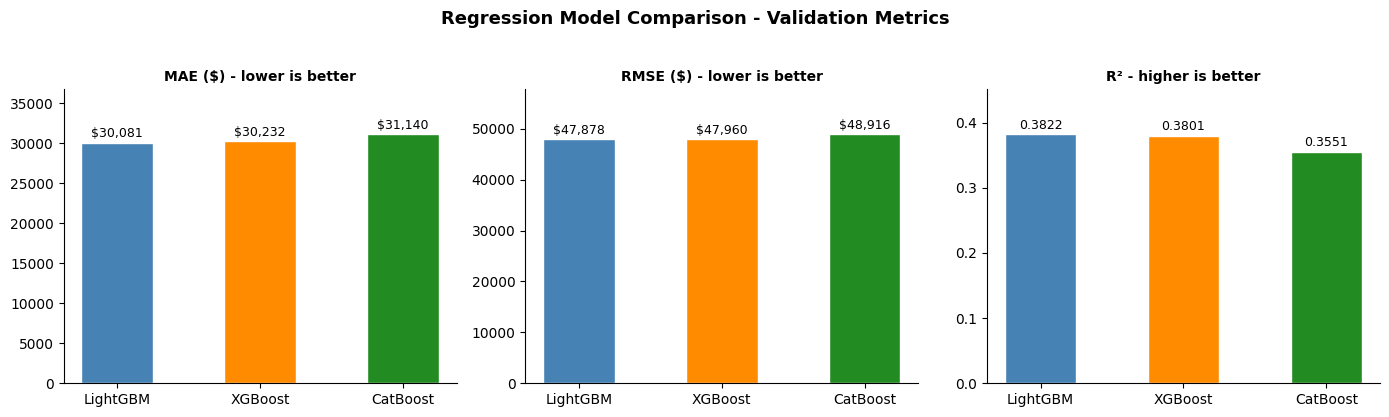


Best model by MAE: LightGBM
  MAE:  $30,081
  RMSE: $47,878
  R²:   0.3822


In [133]:
from math import pi

# Metrics collected from all three models
model_names_cmp = ['LightGBM', 'XGBoost', 'CatBoost']
colors_cmp      = ['steelblue', 'darkorange', 'forestgreen']

model_metrics = {
    'LightGBM': {'MAE': mae,     'RMSE': rmse,     'R²': r2},
    'XGBoost':  {'MAE': xgb_mae, 'RMSE': xgb_rmse, 'R²': xgb_r2},
    'CatBoost': {'MAE': cb_mae,  'RMSE': cb_rmse,  'R²': cb_r2},
}
model_preds_cmp = {
    'LightGBM': val_preds,
    'XGBoost':  xgb_val_preds,
    'CatBoost': cb_val_preds,
}

comparison_df = pd.DataFrame(model_metrics).T
comparison_df.index.name = 'Model'
print(comparison_df.to_string(float_format=lambda x: f'${x:,.0f}' if x > 1 else f'{x:.4f}'))

# Graph 1: MAE / RMSE / R² grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, label, invert in [
    (axes[0], 'MAE',  'MAE ($) - lower is better',  True),
    (axes[1], 'RMSE', 'RMSE ($) - lower is better', True),
    (axes[2], 'R²',   'R² - higher is better',      False),
]:
    vals = [model_metrics[m][metric] for m in model_names_cmp]
    bars = ax.bar(model_names_cmp, vals, color=colors_cmp, edgecolor='white', width=0.5)
    fmt = '${:,.0f}' if metric in ('MAE', 'RMSE') else '{:.4f}'
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Regression Model Comparison - Validation Metrics', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Best model summary
best = min(model_metrics, key=lambda m: model_metrics[m]['MAE'])
print(f"\nBest model by MAE: {best}")
print(f"  MAE:  ${model_metrics[best]['MAE']:,.0f}")
print(f"  RMSE: ${model_metrics[best]['RMSE']:,.0f}")
print(f"  R²:   {model_metrics[best]['R²']:.4f}")


## 7. Create Dataset Versions

Four variants of the feature matrix are produced from the original v1 dataset.
Each variant tests a different way of handling the missing salary:

| Version | `normalized_salary` | `salary_is_missing` flag |
|---------|---------------------|--------------------------|
| v1 | NaN (original) | - |
| v2 | LightGBM regression fill | - |
| v3 | LightGBM regression fill | ✓ |
| v4 | NaN (original) | ✓ |

In [134]:
df_train_orig = pd.read_csv(TRAIN_PATH)
df_test_orig  = pd.read_csv(TEST_PATH)

train_missing = df_train_orig[TARGET].isna()
test_missing  = df_test_orig[TARGET].isna()

print(f"Missing salary - train: {train_missing.sum():,}  test: {test_missing.sum():,}")

# v2: NaN salaries → LightGBM regression predictions
df_train_v2 = df_train_orig.copy()
df_test_v2  = df_test_orig.copy()
df_train_v2.loc[train_missing, TARGET] = lgbm_model.predict(df_train_orig.loc[train_missing, feature_cols])
df_test_v2.loc[test_missing,   TARGET] = lgbm_model.predict(df_test_orig.loc[test_missing,   feature_cols])

# v3: regressed salaries + salary_is_missing flag
df_train_v3 = df_train_v2.copy()
df_test_v3  = df_test_v2.copy()
df_train_v3['salary_is_missing'] = train_missing.astype(int)
df_test_v3['salary_is_missing']  = test_missing.astype(int)

# v4: original NaN salaries + salary_is_missing flag (no regression)
df_train_v4 = df_train_orig.copy()
df_test_v4  = df_test_orig.copy()
df_train_v4['salary_is_missing'] = train_missing.astype(int)
df_test_v4['salary_is_missing']  = test_missing.astype(int)

# Summary
print(f"\n{'Version':<28}  {'Shape':<16}  {'Salary NaN':>12}  {'Flag':>6}")
print("-" * 68)
for label, df in [
    ("v1 (original)",       df_train_orig),
    ("v2 (regressed)",      df_train_v2),
    ("v3 (regressed+flag)", df_train_v3),
    ("v4 (flag only)",      df_train_v4),
]:
    nan_count = df[TARGET].isna().sum()
    has_flag  = "salary_is_missing" in df.columns
    print(f"{label:<28}  {str(df.shape):<16}  {nan_count:>12,}  {str(has_flag):>6}")

Missing salary - train: 62,448  test: 15,750

Version                       Shape               Salary NaN    Flag
--------------------------------------------------------------------
v1 (original)                 (98589, 44)             62,448   False
v2 (regressed)                (98589, 44)                  0   False
v3 (regressed+flag)           (98589, 45)                  0    True
v4 (flag only)                (98589, 45)             62,448    True


## 8. Export Dataset Versions

In [135]:
import os

DATASET_EXPORTS = {
    "v2": (df_train_v2, df_test_v2,
           "../data/processed/v2/feature_matrix_train_v2.csv",
           "../data/processed/v2/feature_matrix_test_v2.csv"),
    "v3": (df_train_v3, df_test_v3,
           "../data/processed/v3/feature_matrix_train_v3.csv",
           "../data/processed/v3/feature_matrix_test_v3.csv"),
    "v4": (df_train_v4, df_test_v4,
           "../data/processed/v4/feature_matrix_train_v4.csv",
           "../data/processed/v4/feature_matrix_test_v4.csv"),
}

for ver, (df_tr, df_te, train_path, test_path) in DATASET_EXPORTS.items():
    os.makedirs(os.path.dirname(train_path), exist_ok=True)
    df_tr.to_csv(train_path, index=False)
    df_te.to_csv(test_path,  index=False)
    print(f"{ver}  train {df_tr.shape} → {train_path}")
    print(f"     test  {df_te.shape} → {test_path}")

v2  train (98589, 44) → ../data/processed/v2/feature_matrix_train_v2.csv
     test  (24709, 44) → ../data/processed/v2/feature_matrix_test_v2.csv
v3  train (98589, 45) → ../data/processed/v3/feature_matrix_train_v3.csv
     test  (24709, 45) → ../data/processed/v3/feature_matrix_test_v3.csv
v4  train (98589, 45) → ../data/processed/v4/feature_matrix_train_v4.csv
     test  (24709, 45) → ../data/processed/v4/feature_matrix_test_v4.csv


## Summary

| Step | Detail |
|------|--------|
| Regressor | LightGBM (early stopping, MAE objective) |
| Competitors | XGBoost, CatBoost — compared in Section 6, LightGBM selected |
| Imputation | LightGBM predictions fill the ~63% of rows missing `normalized_salary` |
| Datasets | Four versions produced: v1 original, v2 regressed, v3 regressed+flag, v4 flag-only |
| Outputs | `data/processed/v{2,3,4}/feature_matrix_{train,test}_v{2,3,4}.csv` |

## 9. LightGBM Classifier Comparison Across Dataset Versions

Train a LightGBM classifier on each of the four dataset versions and compare classification performance.
This reveals whether salary regression imputation and/or the `salary_is_missing` flag provide additional signal for predicting `experience_level_ord`.

In [136]:
from src.models.train.train_lightgbm import train_lgbm_classifier, get_feature_importance as lgbm_clf_fi
from src.utils.evaluation import compute_metrics, EXPERIENCE_LABELS

warnings.filterwarnings("ignore")

TARGET_CLF    = 'experience_level_ord'
DATASET_COLORS = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

dataset_configs = {
    "v1 (original)":       ("../data/processed/v1/feature_matrix_train.csv",
                             "../data/processed/v1/feature_matrix_test.csv"),
    "v2 (regressed)":      ("../data/processed/v2/feature_matrix_train_v2.csv",
                             "../data/processed/v2/feature_matrix_test_v2.csv"),
    "v3 (regressed+flag)": ("../data/processed/v3/feature_matrix_train_v3.csv",
                             "../data/processed/v3/feature_matrix_test_v3.csv"),
    "v4 (flag only)":      ("../data/processed/v4/feature_matrix_train_v4.csv",
                             "../data/processed/v4/feature_matrix_test_v4.csv"),
}

clf_results  = {}
clf_models   = {}
clf_preds    = {}
clf_y_tests  = {}
clf_features = {}

for version, (train_path, test_path) in dataset_configs.items():
    print(f"\n{'='*60}\n  {version}\n{'='*60}")

    df_tr = pd.read_csv(train_path).dropna(subset=[TARGET_CLF]).reset_index(drop=True)
    df_te = pd.read_csv(test_path).dropna(subset=[TARGET_CLF]).reset_index(drop=True)

    feats  = [c for c in df_tr.columns if c != TARGET_CLF]
    X_tr   = df_tr[feats]
    y_tr   = df_tr[TARGET_CLF].astype(int)
    X_te   = df_te[feats]
    y_te   = df_te[TARGET_CLF].astype(int)

    model  = train_lgbm_classifier(X_tr, y_tr)
    y_pred = model.predict(X_te)

    clf_results[version]  = compute_metrics(y_te, y_pred)
    clf_models[version]   = model
    clf_preds[version]    = y_pred
    clf_y_tests[version]  = y_te
    clf_features[version] = feats

    m = clf_results[version]
    print(f"  accuracy={m['accuracy']:.4f}  f1_macro={m['f1_macro']:.4f}  f1_weighted={m['f1_weighted']:.4f}")


  v1 (original)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.12605
[200]	valid_0's multi_logloss: 1.03608
[300]	valid_0's multi_logloss: 0.975742
[400]	valid_0's multi_logloss: 0.935932
[500]	valid_0's multi_logloss: 0.905863
[600]	valid_0's multi_logloss: 0.88376
[700]	valid_0's multi_logloss: 0.868081
[800]	valid_0's multi_logloss: 0.858282
[900]	valid_0's multi_logloss: 0.850587
[1000]	valid_0's multi_logloss: 0.845758
[1100]	valid_0's multi_logloss: 0.842472
[1200]	valid_0's multi_logloss: 0.840255
[1300]	valid_0's multi_logloss: 0.839317
[1400]	valid_0's multi_logloss: 0.839561
Early stopping, best iteration is:
[1328]	valid_0's multi_logloss: 0.838824
  accuracy=0.6631  f1_macro=0.5565  f1_weighted=0.6623

  v2 (regressed)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.12651
[200]	valid_0's multi_logloss: 1.03581
[300]	valid_0's multi_logloss: 0.976576
[400]	valid_0's multi_logloss:

                     accuracy  f1_macro  f1_weighted  precision_macro  recall_macro    mae
Dataset                                                                                   
v1 (original)          0.6631    0.5565       0.6623           0.6223        0.5329 0.5495
v2 (regressed)         0.6568    0.5527       0.6567           0.6065        0.5338 0.5592
v3 (regressed+flag)    0.6603    0.5536       0.6599           0.6078        0.5336 0.5542
v4 (flag only)         0.6630    0.5561       0.6623           0.6136        0.5348 0.5524


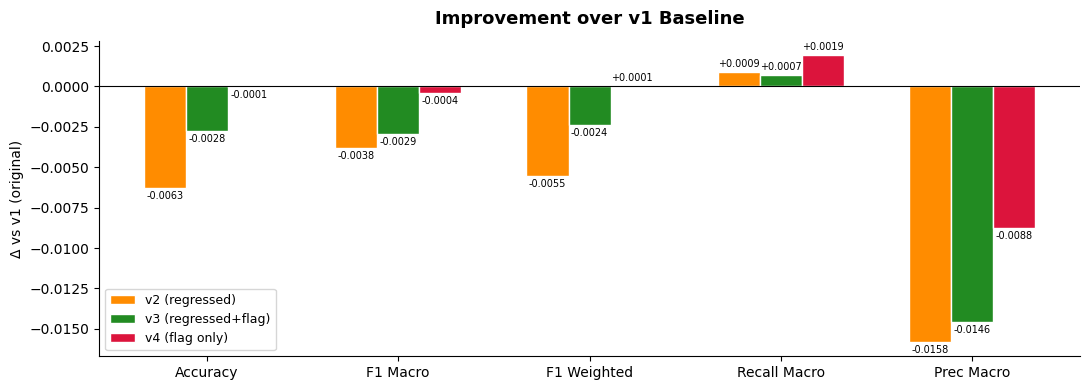


Best dataset version by F1 macro: v1 (original)
  accuracy          : 0.6631
  f1_macro          : 0.5565
  f1_weighted       : 0.6623
  precision_macro   : 0.6223
  recall_macro      : 0.5329
  mae               : 0.5495


In [138]:
dataset_versions = list(clf_results.keys())

# --- Summary table ---
summary_keys = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro', 'mae']
summary_df = pd.DataFrame(
    {v: {k: clf_results[v].get(k, float('nan')) for k in summary_keys}
     for v in dataset_versions}
).T
summary_df.index.name = 'Dataset'
print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))

# --- Delta vs v1 baseline ---
baseline_ver   = 'v1 (original)'
delta_metrics  = ['accuracy', 'f1_macro', 'f1_weighted', 'recall_macro', 'precision_macro']
delta_labels   = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Recall Macro', 'Prec Macro']
other_versions = [v for v in dataset_versions if v != baseline_ver]

fig, ax = plt.subplots(figsize=(11, 4))
x_d = np.arange(len(delta_metrics))
w_d = 0.22

for i, (ver, color) in enumerate(zip(other_versions, DATASET_COLORS[1:])):
    deltas = [clf_results[ver].get(m, 0) - clf_results[baseline_ver].get(m, 0)
              for m in delta_metrics]
    bars = ax.bar(x_d + i * w_d, deltas, w_d, label=ver, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%+.4f', fontsize=7, padding=2)

ax.set_xticks(x_d + w_d * (len(other_versions) - 1) / 2)
ax.set_xticklabels(delta_labels, fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel(f'Δ vs {baseline_ver}')
ax.set_title('Improvement over v1 Baseline', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- Best version summary ---
best_ver = max(clf_results, key=lambda v: clf_results[v]['f1_macro'])
print(f"\nBest dataset version by F1 macro: {best_ver}")
for k in summary_keys:
    print(f"  {k:<18}: {clf_results[best_ver][k]:.4f}")